# 1. Setup și Instalări
Ne asigurăm că avem toate bibliotecile necesare instalate, inclusiv `timm` pentru Inception-ResNet-v2.

In [3]:
# Rulează asta o singură dată
# !pip install timm pandas matplotlib seaborn scikit-learn tqdm

# 2. Explorarea Datelor (EDA)
Verificăm dacă DataLoader-ul nostru încarcă corect imaginile și dacă augmentările (rotații, culori) arată bine pe setul de antrenare.

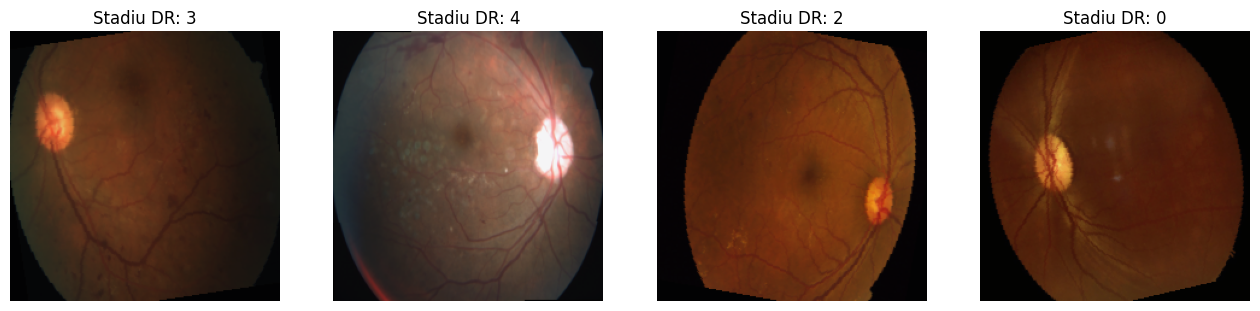

In [4]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from my_dataset import DRDataset

# Schimbă 'aptos' cu ce dataset vrei să vizualizezi
dataset_eda = DRDataset(root_dir='../../', dataset_name='aptos', split='train', image_size=224)
loader_eda = DataLoader(dataset_eda, batch_size=4, shuffle=True)

# Luăm un batch
batch = next(iter(loader_eda))
imagini = batch[0]
etichete = batch[1]

# Afișare
plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    # Convertim din Tensor PyTorch (C, H, W) in Numpy (H, W, C)
    img_viz = imagini[i].permute(1, 2, 0).numpy()
    
    # De-normalizare pentru afișare corectă (valori între 0 și 1)
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img_viz = std * img_viz + mean
    img_viz = img_viz.clip(0, 1)
    
    plt.imshow(img_viz)
    plt.title(f"Stadiu DR: {etichete[i].item()}")
    plt.axis('off')
plt.show()

## Partea 1: Evaluarea Arhitecturilor (8 Experimente)
Păstrăm dataset-ul (APTOS), loss-ul (CE) și learning rate-ul (0.0001) constante. Variem doar arhitectura rețelei pentru a vedea care extrage cele mai bune caracteristici.

*Notă: Modelele Inception necesită rezoluție 299x299. Folosim `num_workers=0` pentru stabilitate în Notebook pe Windows.*

In [5]:
# 1. Baseline (ResNet-50)
%run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/1] | Train Loss: 1.3586 (Acc: 47.8%) | Test Loss: 1.2446 (Acc: 58.2%) | Timp: 0m 54s  --> Model salvat! (Loss nou record: 1.2446)

Antrenamentul s-a terminat!
Graficul combinat a fost salvat ca: Rezultate/salvari_grafice_multi/grafic_resnet50_aptos.png


In [6]:
# 2. ResNet-34 (Versiunea mai ușoară)
%run train.py --dataset aptos --model resnet34 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet34 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/1] | Train Loss: 1.3661 (Acc: 46.0%) | Test Loss: 1.1371 (Acc: 54.9%) | Timp: 1m 10s  --> Model salvat! (Loss nou record: 1.1371)

Antrenamentul s-a terminat!
Graficul combinat a fost salvat ca: Rezultate/salvari_grafice_multi/grafic_resnet34_aptos.png


In [7]:
# 3. EfficientNet-B0
%run train.py --dataset aptos --model efficientnet_b0 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: efficientnet_b0 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/1] | Train Loss: 0.9031 (Acc: 68.9%) | Test Loss: 0.5686 (Acc: 77.0%) | Timp: 1m 8s  --> Model salvat! (Loss nou record: 0.5686)

Antrenamentul s-a terminat!
Graficul combinat a fost salvat ca: Rezultate/salvari_grafice_multi/grafic_efficientnet_b0_aptos.png


In [8]:
# 4. EfficientNet-B3
%run train.py --dataset aptos --model efficientnet_b3 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: efficientnet_b3 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/1] | Train Loss: 0.9672 (Acc: 68.1%) | Test Loss: 0.6151 (Acc: 77.3%) | Timp: 1m 31s  --> Model salvat! (Loss nou record: 0.6151)

Antrenamentul s-a terminat!
Graficul combinat a fost salvat ca: Rezultate/salvari_grafice_multi/grafic_efficientnet_b3_aptos.png


In [9]:
# 5. DenseNet-121
%run train.py --dataset aptos --model densenet121 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: densenet121 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/1] | Train Loss: 0.6860 (Acc: 75.3%) | Test Loss: 0.4751 (Acc: 82.8%) | Timp: 1m 17s  --> Model salvat! (Loss nou record: 0.4751)

Antrenamentul s-a terminat!
Graficul combinat a fost salvat ca: Rezultate/salvari_grafice_multi/grafic_densenet121_aptos.png


In [ ]:
# 6. VGG-16 (Model clasic liniar - reducem batch-ul pentru a evita erori de memorie)
%run train.py --dataset aptos --model vgg16 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: vgg16 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...


In [ ]:
# 7. Inception-v3 (Necesită rezoluție 299)
%run train.py --dataset aptos --model inception_v3 --loss ce --lr 0.0001 --img_size 299 --epochs 1 --batch_size 32 --num_workers 8

In [ ]:
# 8. Inception-ResNet-v2 (Cel mai greu model, rezoluție 299)
%run train.py --dataset aptos --model incres_v2 --loss ce --lr 0.0001 --img_size 299 --epochs 1 --batch_size 32 --num_workers 4

## Partea 2: Evaluarea Capacității de Generalizare (4 Dataset-uri)
Păstrăm arhitectura (ResNet-50), loss-ul (CE) și LR-ul (0.0001) constante. Testăm cum se comportă același model pe baze de date cu distribuții, dimensiuni și calități diferite.
*(Experimentul pe APTOS a fost deja rulat în Partea 1, dar îl putem include pentru completitudine).*

In [ ]:
# 1. APTOS (Baseline-ul deja testat)
# %run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 15 --num_workers 0

In [ ]:
# 2. IDRiD (Set mic, imagini de înaltă calitate, dezechilibrat)
%run train.py --dataset idrid --model resnet50 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 4

In [ ]:
# 3. Messidor-2 (Standardul de aur medical, grading strict)
%run train.py --dataset messidor2 --model resnet50 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 4

In [ ]:
# 4. Kaggle EyePACS (Set masiv, mult zgomot, reducem batch-ul)
%run train.py --dataset eyepacs --model resnet50 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 4

## Partea 3: Impactul Funcției de Pierdere (4 Loss-uri)
Păstrăm dataset-ul (APTOS), modelul (ResNet-50) și LR-ul (0.0001) constante. Variem modul în care modelul este penalizat pentru greșeli.

In [ ]:
# 1. CrossEntropy (Baseline-ul deja testat)
%run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/20] | Train Loss: 1.3812 (Acc: 47.6%) | Test Loss: 1.2374 (Acc: 57.1%) | Timp: 0m 48s  --> Model salvat! (Loss nou record: 1.2374)
Epoca [2/20] | Train Loss: 1.1958 (Acc: 58.5%) | Test Loss: 1.1452 (Acc: 66.7%) | Timp: 0m 47s  --> Model salvat! (Loss nou record: 1.1452)
Epoca [3/20] | Train Loss: 1.1059 (Acc: 64.3%) | Test Loss: 1.0618 (Acc: 71.0%) | Timp: 0m 56s  --> Model salvat! (Loss nou record: 1.0618)
Epoca [4/20] | Train Loss: 1.0380 (Acc: 67.1%) | Test Loss: 0.9916 (Acc: 71.3%) | Timp: 0m 54s  --> Model salvat! (Loss nou record: 0.9916)
Epoca [5/20] | Train Loss: 1.0010 (Acc: 68.0%) | Test Loss: 0.9368 (Acc: 71.9%) | Timp: 0m 54s  --> Model salvat! (Loss nou record: 0.9368)
Epoca [6/20] | Train Loss: 0.9532 (Acc: 69.4%) | Test Loss: 0.9223 (Acc: 72.1%) | Timp: 0m 56s  --> Model salvat! (Loss nou record: 0.9223)
Epoca [7/20] | Train L

In [ ]:
# 2. Regresie Ordinală cu BCE (Ține cont de progresia bolii: 0 -> 1 -> 2 -> 3 -> 4)
%run train.py --dataset aptos --model resnet50 --loss bce_ordinal --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/20] | Train Loss: 0.5366 (Acc: 47.2%) | Test Loss: 0.4612 (Acc: 54.4%) | Timp: 0m 45s  --> Model salvat! (Loss nou record: 0.4612)


KeyboardInterrupt: 

In [ ]:
# 3. Focal Loss (Penalizează mai tare exemplele "grele")
%run train.py --dataset aptos --model resnet50 --loss focal_loss --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/20] | Train Loss: 0.8165 (Acc: 48.1%) | Test Loss: 0.6912 (Acc: 62.8%) | Timp: 0m 56s  --> Model salvat! (Loss nou record: 0.6912)


KeyboardInterrupt: 

In [ ]:
# 4. Weighted CrossEntropy (Ajută clasele minoritare - stadiile 3 și 4)
%run train.py --dataset aptos --model resnet50 --loss weighted_ce --lr 0.0001 --epochs 1 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366


ValueError: Pentru Weighted CrossEntropy, trebuie să transmiți tensorul 'class_weights'!

## Partea 4: Sensibilitatea la Learning Rate (2 LR-uri)
Păstrăm dataset-ul (APTOS), modelul (ResNet-50) și Loss-ul (CE) constante. Verificăm dacă o viteză de învățare mai mare sau mai mică schimbă punctul de convergență.

In [ ]:
# 1. Learning Rate = 0.0001 (Baseline-ul deja testat)
# %run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 15 --num_workers 0

In [ ]:
# 2. Learning Rate = 0.001 (Învățare de 10 ori mai rapidă, risc mai mare de instabilitate)
%run train.py --dataset aptos --model resnet50 --loss ce --lr 0.001 --epochs 1 --batch_size 32 --num_workers 4

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...


KeyboardInterrupt: 